# MEMIT on Llama 3.1 8B — Port + Hyperparameter Sweeps

This notebook ports MEMIT to Llama 3.1 8B and runs three hyperparameter sweeps:
- **(a) Layer sweep:** vary the set of edited layers R
- **(b) λ sweep:** vary `mom2_update_weight` (covariance weighting)
- **(c) Edit count scaling:** vary n from 100 to 10,000

## 1. Fix CUDA Memory Allocation + Check GPU
Requires A100 (40GB) for Llama 3.1 8B in float16.

In [ ]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
!nvidia-smi

Fri Apr 17 03:50:10 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P0             50W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

## 2. Clone MEMIT Repository

In [ ]:
%cd /content
!rm -rf memit
!git clone https://github.com/kmeng01/memit.git
%cd /content/memit

/content
Cloning into 'memit'...
remote: Enumerating objects: 196, done.
remote: Counting objects: 100% (95/95), done.
remote: Compressing objects: 100% (55/55), done.
remote: Total 196 (delta 47), reused 40 (delta 40), pack-reused 101 (from 1)
Receiving objects: 100% (196/196), 134.89 KiB | 2.50 MiB/s, done.
Resolving deltas: 100% (59/59), done.
/content/memit


## 3. Install Dependencies

In [ ]:
!pip install -q matplotlib scipy
!pip install -q transformers==4.45.0 accelerate tokenizers
!pip install -q datasets==2.14.7
!pip install -q nltk scikit-learn
import nltk
nltk.download('punkt_tab', quiet=True)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 92.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 116.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 54.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 520.4/520.4 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.3/115.3 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.4/166.4 kB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.4/135.4 kB 17.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2023.10.0 which is incompatible.


True

## 4. HuggingFace Login

Llama 3.1 8B is a gated model. You must:
1. Accept the license at https://huggingface.co/meta-llama/Llama-3.1-8B
2. Create an access token at https://huggingface.co/settings/tokens
3. Run the cell below and paste your token

In [ ]:
!pip install -q huggingface_hub
!huggingface-cli login

⚠️  Warning: 'huggingface-cli login' is deprecated. Use 'hf auth login' instead.

    _|    _|  _|    _|    _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|_|_|_|    _|_|      _|_|_|  _|_|_|_|
    _|    _|  _|    _|  _|        _|          _|    _|_|    _|  _|            _|        _|    _|  _|        _|
    _|_|_|_|  _|    _|  _|  _|_|  _|  _|_|    _|    _|  _|  _|  _|  _|_|      _|_|_|    _|_|_|_|  _|        _|_|_|
    _|    _|  _|    _|  _|    _|  _|    _|    _|    _|    _|_|  _|    _|      _|        _|    _|  _|        _|
    _|    _|    _|_|      _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|        _|    _|    _|_|_|  _|_|_|_|

    To log in, `huggingface_hub` requires a token generated from https://huggingface.co/settings/tokens .
Enter your token (input will not be visible): 
Add token as git credential? (Y/n) n
Token is valid (permission: write).
The token `MEMIT` has been saved to /root/.cache/huggingface/stored_tokens
Your token has been saved to /root/.cache/hug

## 5. Compatibility Patches

Patches 1-4 fix the MEMIT codebase for Python 3.12 / PyTorch 2.x / newer scipy+sklearn.
Patches 5-6 fix assumptions specific to GPT-J that break on Llama.

In [ ]:
# ============================================================
# PATCH 1: nethook.py — Fix hook to capture both inputs+output in PyTorch 2.x
# ============================================================

nethook_path = "/content/memit/util/nethook.py"
with open(nethook_path, "r") as f:
    code_text = f.read()

old_hook = "def retain_hook(m, inputs, output):"
new_hook = """def retain_hook(m, *hook_args, **hook_kwargs):
            # Extract inputs and output from variable args (PyTorch 2.x compat)
            if hook_args:
                inputs = hook_args[0] if len(hook_args) > 1 else ()
                output = hook_args[-1]
            else:
                inputs = hook_kwargs.get('input', hook_kwargs.get('inputs', ()))
                output = hook_kwargs.get('output', None)
            if not isinstance(inputs, tuple):
                inputs = (inputs,)"""

if old_hook in code_text:
    code_text = code_text.replace(old_hook, new_hook)
    code_text = code_text.replace(
        "self.registered_hook = module.register_forward_hook(retain_hook)",
        "self.registered_hook = module.register_forward_hook(retain_hook, with_kwargs=True)"
    )
    with open(nethook_path, "w") as f:
        f.write(code_text)
    print("PATCH 1 applied: nethook.py hook fixed for PyTorch 2.x")
else:
    print("PATCH 1: already applied or different version")

PATCH 1 applied: nethook.py hook fixed for PyTorch 2.x


In [ ]:
# ============================================================
# PATCH 2: repr_tools.py — Handle empty tuples from hooks
# ============================================================

repr_path = "/content/memit/rome/repr_tools.py"
with open(repr_path, "r") as f:
    code_text = f.read()

old_line = "cur_repr = cur_repr[0] if type(cur_repr) is tuple else cur_repr"
new_line = "cur_repr = cur_repr[0] if (isinstance(cur_repr, tuple) and len(cur_repr) > 0) else cur_repr"

if old_line in code_text:
    code_text = code_text.replace(old_line, new_line)
    with open(repr_path, "w") as f:
        f.write(code_text)
    print("PATCH 2 applied: repr_tools.py empty tuple guard")
else:
    print("PATCH 2: already applied")

PATCH 2 applied: repr_tools.py empty tuple guard


In [ ]:
# ============================================================
# PATCH 3: tfidf_stats.py — Fix for newer scikit-learn
# ============================================================

tfidf_path = "/content/memit/dsets/tfidf_stats.py"

new_content = """import json
from itertools import chain
from pathlib import Path

import numpy as np
import scipy.sparse as sp
import torch
from sklearn.feature_extraction.text import TfidfVectorizer, TfidfTransformer

from dsets import AttributeSnippets
from util.globals import *

REMOTE_IDF_URL = f"{REMOTE_ROOT_URL}/data/dsets/idf.npy"
REMOTE_VOCAB_URL = f"{REMOTE_ROOT_URL}/data/dsets/tfidf_vocab.json"


def get_tfidf_vectorizer(data_dir: str):
    data_dir = Path(data_dir)

    idf_loc, vocab_loc = data_dir / "idf.npy", data_dir / "tfidf_vocab.json"
    if not (idf_loc.exists() and vocab_loc.exists()):
        collect_stats(data_dir)

    idf = np.load(idf_loc)
    with open(vocab_loc, "r") as f:
        vocab = json.load(f)

    vec = TfidfVectorizer()
    vec.vocabulary_ = vocab
    vec.fixed_vocabulary_ = True
    vec.stop_words_ = set()
    vec._tfidf = TfidfTransformer()
    vec._tfidf._idf_diag = sp.spdiags(idf, diags=0, m=len(idf), n=len(idf))
    vec._tfidf.n_features_in_ = len(idf)

    return vec


def collect_stats(data_dir: str):
    data_dir = Path(data_dir)
    data_dir.mkdir(exist_ok=True, parents=True)
    idf_loc, vocab_loc = data_dir / "idf.npy", data_dir / "tfidf_vocab.json"

    try:
        print(f"Downloading IDF cache from {REMOTE_IDF_URL}")
        torch.hub.download_url_to_file(REMOTE_IDF_URL, idf_loc)
        print(f"Downloading TF-IDF vocab cache from {REMOTE_VOCAB_URL}")
        torch.hub.download_url_to_file(REMOTE_VOCAB_URL, vocab_loc)
        return
    except Exception as e:
        print(f"Error downloading file:", e)
        print("Recomputing TF-IDF stats...")

    snips_list = AttributeSnippets(data_dir).snippets_list
    documents = list(chain(*[[y["text"] for y in x["samples"]] for x in snips_list]))

    vec = TfidfVectorizer()
    vec.fit(documents)

    idfs = vec.idf_
    vocab = vec.vocabulary_

    np.save(data_dir / "idf.npy", idfs)
    with open(data_dir / "tfidf_vocab.json", "w") as f:
        json.dump(vocab, f, indent=1)
"""

with open(tfidf_path, "w") as f:
    f.write(new_content)

print("PATCH 3 applied: tfidf_stats.py full rewrite")

PATCH 3 applied: tfidf_stats.py full rewrite


In [ ]:
# ============================================================
# PATCH 4: eval_utils_counterfact.py — Fix deprecated APIs
# ============================================================

eval_utils_path = "/content/memit/experiments/py/eval_utils_counterfact.py"

with open(eval_utils_path, "r") as f:
    lines = f.readlines()

new_lines = []
for line in lines:
    line = line.replace("scipy.stats.mstats.gmean", "scipy.stats.gmean")
    line = line.replace(").A", ").toarray()")
    new_lines.append(line)
    if line.strip() == "import scipy":
        new_lines.append("import scipy.stats\n")

with open(eval_utils_path, "w") as f:
    f.writelines(new_lines)

print("PATCH 4 applied: gmean + import + .toarray()")

PATCH 4 applied: gmean + import + .toarray()


In [ ]:
# ============================================================
# PATCH 5: layer_stats.py — Fix Wikipedia dataset version
# ============================================================

layer_stats_path = "/content/memit/rome/layer_stats.py"

with open(layer_stats_path, "r") as f:
    code_text = f.read()

code_text = code_text.replace('20200501.en', '20220301.en')

with open(layer_stats_path, "w") as f:
    f.write(code_text)

print("PATCH 5 applied: Wikipedia 20200501.en -> 20220301.en")

PATCH 5 applied: Wikipedia 20200501.en -> 20220301.en


## 6. Create Llama 3.1 8B Hyperparameters

In [ ]:
import json
import os

os.makedirs("/content/memit/hparams/MEMIT", exist_ok=True)

llama_hparams = {
    "layers": [4, 5, 6, 7, 8, 9],
    "clamp_norm_factor": 0.75,
    "layer_selection": "all",
    "fact_token": "subject_last",
    "v_num_grad_steps": 25,
    "v_lr": 5e-1,
    "v_loss_layer": 31,
    "v_weight_decay": 0.5,
    "kl_factor": 0.0625,
    "mom2_adjustment": True,
    "mom2_update_weight": 15000,
    "rewrite_module_tmp": "model.layers.{}.mlp.down_proj",
    "layer_module_tmp": "model.layers.{}",
    "mlp_module_tmp": "model.layers.{}.mlp",
    "attn_module_tmp": "model.layers.{}.self_attn",
    "ln_f_module": "model.norm",
    "lm_head_module": "lm_head",
    "mom2_dataset": "wikipedia",
    "mom2_n_samples": 100000,
    "mom2_dtype": "float32"
}

hparams_path = "/content/memit/hparams/MEMIT/meta-llama_Llama-3.1-8B.json"
with open(hparams_path, "w") as f:
    json.dump(llama_hparams, f, indent=4)

print(f"Llama hparams saved to {hparams_path}")
print(json.dumps(llama_hparams, indent=2))

Llama hparams saved to /content/memit/hparams/MEMIT/meta-llama_Llama-3.1-8B.json
{
  "layers": [
    4,
    5,
    6,
    7,
    8,
    9
  ],
  "clamp_norm_factor": 0.75,
  "layer_selection": "all",
  "fact_token": "subject_last",
  "v_num_grad_steps": 25,
  "v_lr": 0.5,
  "v_loss_layer": 31,
  "v_weight_decay": 0.5,
  "kl_factor": 0.0625,
  "mom2_adjustment": true,
  "mom2_update_weight": 15000,
  "rewrite_module_tmp": "model.layers.{}.mlp.down_proj",
  "layer_module_tmp": "model.layers.{}",
  "mlp_module_tmp": "model.layers.{}.mlp",
  "attn_module_tmp": "model.layers.{}.self_attn",
  "ln_f_module": "model.norm",
  "lm_head_module": "lm_head",
  "mom2_dataset": "wikipedia",
  "mom2_n_samples": 100000,
  "mom2_dtype": "float32"
}


## 7. Load Llama 3.1 8B

In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

MODEL_NAME = "meta-llama/Llama-3.1-8B"

print(f"Loading {MODEL_NAME}...")
tok = AutoTokenizer.from_pretrained(MODEL_NAME)
tok.pad_token = tok.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
).cuda()

print(f"Model loaded! Parameters: {sum(p.numel() for p in model.parameters()) / 1e9:.1f}B")
print(f"GPU memory used: {torch.cuda.memory_allocated() / 1e9:.1f} GB")

Loading meta-llama/Llama-3.1-8B...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/73.0 [00:00<?, ?B/s]

...

model-00003-of-00004.safetensors:   0%|          | 0.00/4.92G [00:00<?, ?B/s]

model-00004-of-00004.safetensors:   0%|          | 0.00/1.17G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/185 [00:00<?, ?B/s]

Model loaded! Parameters: 8.0B
GPU memory used: 16.1 GB


In [ ]:
# ============================================================
# PATCH 6: Fix GPT-J config attribute names for Llama
# ============================================================
# MEMIT codebase uses GPT-J config names. Llama uses different names.
# CRITICAL: n_positions is used in layer_stats.py to set batch_tokens = n_positions * 3.
# Llama's max_position_embeddings = 131072 (128K context), which would create
# batches of 393K tokens and OOM even on H100. Cap at 2048 to match GPT-J behavior.

if not hasattr(model.config, "n_embd"):
    model.config.n_embd = model.config.hidden_size
    print(f"  n_embd = {model.config.n_embd}")

if not hasattr(model.config, "n_positions"):
    model.config.n_positions = min(getattr(model.config, "max_position_embeddings", 2048), 2048)
    print(f"  n_positions = {model.config.n_positions} (capped at 2048 for MEMIT batch sizing)")

if not hasattr(model.config, "n_layer"):
    model.config.n_layer = model.config.num_hidden_layers
    print(f"  n_layer = {model.config.n_layer}")

print("PATCH 6 applied: all config aliases set.")

  n_embd = 4096
  n_positions = 2048 (capped at 2048 for MEMIT batch sizing)
  n_layer = 32
PATCH 6 applied: all config aliases set.


## 8. Sanity Check — Single MEMIT Edit on Llama

In [ ]:
import sys
import gc
sys.path.insert(0, "/content/memit")

from memit import MEMITHyperParams, apply_memit_to_model

hparams = MEMITHyperParams.from_json("hparams/MEMIT/meta-llama_Llama-3.1-8B.json")

request = [
    {
        "prompt": "{} plays the sport of",
        "subject": "LeBron James",
        "target_new": {"str": "tennis"},
    }
]

print("Before edit:")
inputs = tok("LeBron James plays the sport of", return_tensors="pt").to("cuda")
with torch.no_grad():
    out = model.generate(**inputs, max_new_tokens=10, do_sample=False)
print(f"  {tok.decode(out[0], skip_special_tokens=True)}")

# Free generation tensors before MEMIT's heavy optimization loop
del inputs, out
gc.collect()
torch.cuda.empty_cache()

print("\nApplying MEMIT edit...")
edited_model, weights_copy = apply_memit_to_model(
    model, tok, request, hparams, copy=False, return_orig_weights=True
)

print("\nAfter edit:")
inputs = tok("LeBron James plays the sport of", return_tensors="pt").to("cuda")
with torch.no_grad():
    out = edited_model.generate(**inputs, max_new_tokens=10, do_sample=False)
print(f"  {tok.decode(out[0], skip_special_tokens=True)}")

# Restore
with torch.no_grad():
    for k, v in weights_copy.items():
        from util import nethook
        nethook.get_parameter(model, k)[...] = v.to("cuda")
print("\nWeights restored.")

/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:601: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.6` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:606: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.9` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:None for open-end generation.


Before edit:


Starting from v4.46, the `logits` model output will have the same type as the model (except at train time, where it will always be FP32)


  LeBron James plays the sport of basketball. He is a professional basketball player for the

Applying MEMIT edit...
MEMIT request sample: [LeBron James plays the sport of] -> [ tennis]


We detected that you are passing `past_key_values` as a tuple of tuples. This is deprecated and will be removed in v4.47. Please convert your cache or use an appropriate `Cache` class (https://huggingface.co/docs/transformers/kv_cache#legacy-cache-format)


...

orig norm tensor(89.1875, device='cuda:0', dtype=torch.float16)
upd norm tensor(0.4209, device='cuda:0', dtype=torch.float64,
       grad_fn=<LinalgVectorNormBackward0>)


LAYER 9

Writing 1 key/value pair(s) into layer 9
z error tensor(3.9608, device='cuda:0', grad_fn=<MeanBackward0>)
Retrieving covariance statistics for meta-llama_Llama-3.1-8B @ model.layers.9.mlp.down_proj.
Attempting to download meta-llama_Llama-3.1-8B/wikipedia_stats/model.layers.9.mlp.down_proj_float32_mom2_100000.npz from https://memit.baulab.info/data/stats/meta-llama_Llama-3.1-8B/wikipedia_stats/model.layers.9.mlp.down_proj_float32_mom2_100000.npz.
Unable to download due to HTTP Error 404: Not Found. Computing locally....


  0%|          | 0/1000 [00:00<?, ?it/s]

orig norm tensor(89.5625, device='cuda:0', dtype=torch.float16)
upd norm tensor(0.6629, device='cuda:0', dtype=torch.float64,
       grad_fn=<LinalgVectorNormBackward0>)


Setting `pad_token_id` to `eos_token_id`:None for open-end generation.


Deltas successfully computed for ['model.layers.4.mlp.down_proj.weight', 'model.layers.5.mlp.down_proj.weight', 'model.layers.6.mlp.down_proj.weight', 'model.layers.7.mlp.down_proj.weight', 'model.layers.8.mlp.down_proj.weight', 'model.layers.9.mlp.down_proj.weight']
New weights successfully inserted into ['model.layers.4.mlp.down_proj.weight', 'model.layers.5.mlp.down_proj.weight', 'model.layers.6.mlp.down_proj.weight', 'model.layers.7.mlp.down_proj.weight', 'model.layers.8.mlp.down_proj.weight', 'model.layers.9.mlp.down_proj.weight']

After edit:
  LeBron James plays the sport of basketball for a living, but he’s also a

Weights restored.


## 9. Load Evaluation Infrastructure

In [ ]:
import json
import numpy as np
from pathlib import Path
from time import time
from itertools import islice
from scipy.stats import hmean

from dsets import (
    AttributeSnippets,
    CounterFactDataset,
    MultiCounterFactDataset,
    get_tfidf_vectorizer,
)
from experiments.py.eval_utils_counterfact import compute_rewrite_quality_counterfact
from memit import MEMITHyperParams, apply_memit_to_model
from util import nethook
from util.globals import *

print("Evaluation imports loaded!")

Evaluation imports loaded!


## 10. Evaluation Helper Functions

In [ ]:
def run_memit_eval(model, tok, hparams, ds, num_edits, skip_generation=False, gen_test_interval=10):
    snips = AttributeSnippets(DATA_DIR) if not skip_generation else None
    vec = get_tfidf_vectorizer(DATA_DIR) if not skip_generation else None

    all_results = []

    def chunks(arr, n):
        for i in range(0, len(arr), n):
            yield arr[i : i + n]

    chunk_num = 0
    for record_chunks in chunks(ds, num_edits):
        chunk_num += 1
        case_ids = [record["case_id"] for record in record_chunks]
        print(f"  Chunk {chunk_num}: editing {len(record_chunks)} facts (cases {case_ids[0]}-{case_ids[-1]})")

        start = time()
        edited_model, weights_copy = apply_memit_to_model(
            model, tok,
            [{"case_id": r["case_id"], **r["requested_rewrite"]} for r in record_chunks],
            hparams, copy=False, return_orig_weights=True,
        )
        exec_time = time() - start

        for record in record_chunks:
            gen_test_vars = (
                [snips, vec]
                if (record["case_id"] % gen_test_interval == 0 and not skip_generation)
                else [None, None]
            )
            metrics = {
                "case_id": record["case_id"],
                "num_edits": num_edits,
                "post": compute_rewrite_quality_counterfact(
                    edited_model, tok, record, *gen_test_vars
                ),
            }
            all_results.append(metrics)

        with torch.no_grad():
            for k, v in weights_copy.items():
                nethook.get_parameter(model, k)[...] = v.to("cuda")

        print(f"    Edit: {exec_time:.1f}s | Total results: {len(all_results)}")

    return all_results


def compute_metrics(results):
    es_list, ps_list, ns_list = [], [], []
    ge_list, rs_list = [], []

    for r in results:
        post = r["post"]
        rewrite_probs = post["rewrite_prompts_probs"]
        es = np.mean([p["target_new"] < p["target_true"] for p in rewrite_probs])
        es_list.append(es)

        para_probs = post["paraphrase_prompts_probs"]
        ps = np.mean([p["target_new"] < p["target_true"] for p in para_probs])
        ps_list.append(ps)

        neigh_probs = post["neighborhood_prompts_probs"]
        ns = np.mean([p["target_new"] > p["target_true"] for p in neigh_probs])
        ns_list.append(ns)

        if "ngram_entropy" in post:
            ge_list.append(post["ngram_entropy"])
        if "reference_score" in post:
            rs_list.append(post["reference_score"])

    es_mean = np.mean(es_list) * 100
    ps_mean = np.mean(ps_list) * 100
    ns_mean = np.mean(ns_list) * 100
    score = hmean([es_mean, ps_mean, ns_mean]) if min(es_mean, ps_mean, ns_mean) > 0 else 0

    metrics = {"ES": es_mean, "PS": ps_mean, "NS": ns_mean, "S": score}
    if ge_list:
        metrics["GE"] = np.mean(ge_list)
    if rs_list:
        metrics["RS"] = np.mean(rs_list) * 100
    return metrics


def print_metrics(metrics, label=""):
    print(f"\n{'='*50}")
    if label:
        print(f"  {label}")
        print(f"{'='*50}")
    for k, v in metrics.items():
        print(f"  {k:5s}: {v:.1f}")

print("Helper functions defined!")

Helper functions defined!


## 11. Load CounterFact Dataset

In [ ]:
DATASET_SIZE = 500

print("Loading CounterFact dataset...")
ds = MultiCounterFactDataset(DATA_DIR, tok=tok, size=DATASET_SIZE)
print(f"Loaded {len(ds)} records.")

Loading CounterFact dataset...
data/multi_counterfact.json does not exist. Downloading from https://memit.baulab.info/data/dsets/multi_counterfact.json


100%|██████████| 40.9M/40.9M [00:00<00:00, 134MB/s]


Loaded dataset with 500 elements
Loaded 500 records.


---
## Sweep (a): Layer Selection

Vary the set of edited layers R. GPT-J uses layers {3,4,5,6,7,8}.
We test different ranges on Llama to find the optimal set.

In [ ]:
layer_configs = {
    "single_8":     [8],
    "narrow_6_9":   [6, 7, 8, 9],
    "default_4_9":  [4, 5, 6, 7, 8, 9],
    "wide_3_10":    [3, 4, 5, 6, 7, 8, 9, 10],
    "mid_8_13":     [8, 9, 10, 11, 12, 13],
    "deep_12_17":   [12, 13, 14, 15, 16, 17],
}

NUM_EDITS_LAYER_SWEEP = 100
layer_sweep_results = {}

print(f"Running layer sweep with {NUM_EDITS_LAYER_SWEEP} edits per config on {len(ds)} records...")

for config_name, layers in layer_configs.items():
    print(f"\n{'='*60}")
    print(f"Config: {config_name} | Layers: {layers}")
    print(f"{'='*60}")

    hparams = MEMITHyperParams.from_json("hparams/MEMIT/meta-llama_Llama-3.1-8B.json")
    hparams.layers = layers

    results = run_memit_eval(model, tok, hparams, ds, num_edits=NUM_EDITS_LAYER_SWEEP, skip_generation=True)

    metrics = compute_metrics(results)
    layer_sweep_results[config_name] = {"layers": layers, "metrics": metrics}
    print_metrics(metrics, f"{config_name}: layers={layers}")

print("\n\nLayer sweep complete!")
print(f"\n{'Config':<20} {'Layers':<25} {'ES':>6} {'PS':>6} {'NS':>6} {'S':>6}")
print("-" * 70)
for name, data in layer_sweep_results.items():
    m = data["metrics"]
    print(f"{name:<20} {str(data['layers']):<25} {m['ES']:>6.1f} {m['PS']:>6.1f} {m['NS']:>6.1f} {m['S']:>6.1f}")

Streaming output truncated to the last 5000 lines.
loss 6.877 = 6.822 + 0.006 + 0.049 avg prob of [ jazz] 0.0011560063576325774
loss 6.82 = 6.765 + 0.006 + 0.049 avg prob of [ jazz] 0.0012168704997748137
loss 6.712 = 6.657 + 0.006 + 0.049 avg prob of [ jazz] 0.0013411480467766523
loss 6.556 = 6.502 + 0.005 + 0.049 avg prob of [ jazz] 0.00154322967864573
loss 11.2 = 10.135 + 1.016 + 0.049 avg prob of [ jazz] 4.166457802057266e-05
loss 17.293 = 17.239 + 0.005 + 0.049 avg prob of [ jazz] 3.5832748324082786e-08
Init norm 7.65234375 | Delta norm 5.73828125 | Target norm 9.420476913452148
Computing right vector (v)
Lookup index found: 6 | Sentence: New Nintendo 3DS is developed by<|begin_of_text|> | Token:  is
Rewrite layer is 9
Tying optimization objective to 31
Recording initial value of v*
loss 17.744 = 17.744 + 0.0 + 0.0 avg prob of [ Microsoft] 2.0389261834452554e-08
loss 17.617 = 17.562 + 0.006 + 0.049 avg prob of [ Microsoft] 2.5143652493397894e-08
loss 16.934 = 16.879 + 0.006 + 0.049

  0%|          | 0/1000 [00:00<?, ?it/s]

orig norm tensor(89.8125, device='cuda:0', dtype=torch.float16)
upd norm tensor(1.7370, device='cuda:0', dtype=torch.float64,
       grad_fn=<LinalgVectorNormBackward0>)


LAYER 4

Writing 100 key/value pair(s) into layer 4
z error tensor(5.4523, device='cuda:0', grad_fn=<MeanBackward0>)
Retrieving covariance statistics for meta-llama_Llama-3.1-8B @ model.layers.4.mlp.down_proj.
orig norm tensor(87.8750, device='cuda:0', dtype=torch.float16)
upd norm tensor(1.6390, device='cuda:0', dtype=torch.float64,
       grad_fn=<LinalgVectorNormBackward0>)


LAYER 5

Writing 100 key/value pair(s) into layer 5
z error tensor(5.4140, device='cuda:0', grad_fn=<MeanBackward0>)
Retrieving covariance statistics for meta-llama_Llama-3.1-8B @ model.layers.5.mlp.down_proj.
orig norm tensor(88.3125, device='cuda:0', dtype=torch.float16)
upd norm tensor(1.6266, device='cuda:0', dtype=torch.float64,
       grad_fn=<LinalgVectorNormBackward0>)


LAYER 6

Writing 100 key/value pair(s) into layer 6
z error tens

  0%|          | 0/1000 [00:00<?, ?it/s]

Streaming output truncated to the last 5000 lines.
loss 15.259 = 15.004 + 0.206 + 0.049 avg prob of [ Prague] 4.1560508634574944e-07
loss 14.837 = 14.747 + 0.041 + 0.049 avg prob of [ Prague] 6.768968887627125e-07
loss 14.468 = 14.359 + 0.06 + 0.049 avg prob of [ Prague] 8.116395520119113e-07
loss 14.778 = 14.697 + 0.032 + 0.049 avg prob of [ Prague] 9.012901500682347e-07
loss 14.547 = 14.465 + 0.032 + 0.049 avg prob of [ Prague] 5.533881903829752e-07
loss 12.891 = 12.726 + 0.116 + 0.049 avg prob of [ Prague] 3.5292687243781984e-06
loss 13.036 = 12.848 + 0.139 + 0.049 avg prob of [ Prague] 3.353128249727888e-06
loss 13.091 = 12.975 + 0.067 + 0.049 avg prob of [ Prague] 2.5943713808374014e-06
loss 12.122 = 12.018 + 0.054 + 0.049 avg prob of [ Prague] 7.175889095378807e-06
loss 10.545 = 10.437 + 0.059 + 0.049 avg prob of [ Prague] 3.256754280300811e-05
loss 11.009 = 10.883 + 0.077 + 0.049 avg prob of [ Prague] 2.8169239158160053e-05
loss 11.897 = 11.781 + 0.068 + 0.049 avg prob of [ Prag

...

orig norm tensor(92.3750, device='cuda:0', dtype=torch.float16)
upd norm tensor(3.3664, device='cuda:0', dtype=torch.float64,
       grad_fn=<LinalgVectorNormBackward0>)


LAYER 16

Writing 100 key/value pair(s) into layer 16
z error tensor(9.0455, device='cuda:0', grad_fn=<MeanBackward0>)
Retrieving covariance statistics for meta-llama_Llama-3.1-8B @ model.layers.16.mlp.down_proj.
Attempting to download meta-llama_Llama-3.1-8B/wikipedia_stats/model.layers.16.mlp.down_proj_float32_mom2_100000.npz from https://memit.baulab.info/data/stats/meta-llama_Llama-3.1-8B/wikipedia_stats/model.layers.16.mlp.down_proj_float32_mom2_100000.npz.
Unable to download due to HTTP Error 404: Not Found. Computing locally....


  0%|          | 0/1000 [00:00<?, ?it/s]

orig norm tensor(91.3125, device='cuda:0', dtype=torch.float16)
upd norm tensor(4.4325, device='cuda:0', dtype=torch.float64,
       grad_fn=<LinalgVectorNormBackward0>)


LAYER 17

Writing 100 key/value pair(s) into layer 17
z error tensor(7.7805, device='cuda:0', grad_fn=<MeanBackward0>)
Retrieving covariance statistics for meta-llama_Llama-3.1-8B @ model.layers.17.mlp.down_proj.
Attempting to download meta-llama_Llama-3.1-8B/wikipedia_stats/model.layers.17.mlp.down_proj_float32_mom2_100000.npz from https://memit.baulab.info/data/stats/meta-llama_Llama-3.1-8B/wikipedia_stats/model.layers.17.mlp.down_proj_float32_mom2_100000.npz.
Unable to download due to HTTP Error 404: Not Found. Computing locally....


  0%|          | 0/1000 [00:00<?, ?it/s]

Streaming output truncated to the last 5000 lines.
loss 6.269 = 6.239 + 0.005 + 0.025 avg prob of [ Spanish] 0.001965038478374481
loss 6.249 = 6.219 + 0.005 + 0.025 avg prob of [ Spanish] 0.002007437404245138
loss 6.233 = 6.203 + 0.005 + 0.025 avg prob of [ Spanish] 0.0020399733912199736
loss 6.215 = 6.186 + 0.004 + 0.025 avg prob of [ Spanish] 0.002075986471027136
loss 6.193 = 6.163 + 0.004 + 0.025 avg prob of [ Spanish] 0.0021233984734863043
loss 6.161 = 6.132 + 0.004 + 0.025 avg prob of [ Spanish] 0.0021897372789680958
Init norm 15.015625 | Delta norm 11.265625 | Target norm 17.93146514892578
Computing right vector (v)
Lookup index found: 7 | Sentence: Which position does Daniel Royer play? They play as<|begin_of_text|> | Token:  play
Rewrite layer is 17
Tying optimization objective to 31
Recording initial value of v*
loss 18.078 = 18.078 + 0.0 + 0.0 avg prob of [ linebacker] 1.6694787774440556e-08
loss 17.843 = 17.805 + 0.003 + 0.035 avg prob of [ linebacker] 2.0405607870088716e-08

### Layer Sweep Visualization

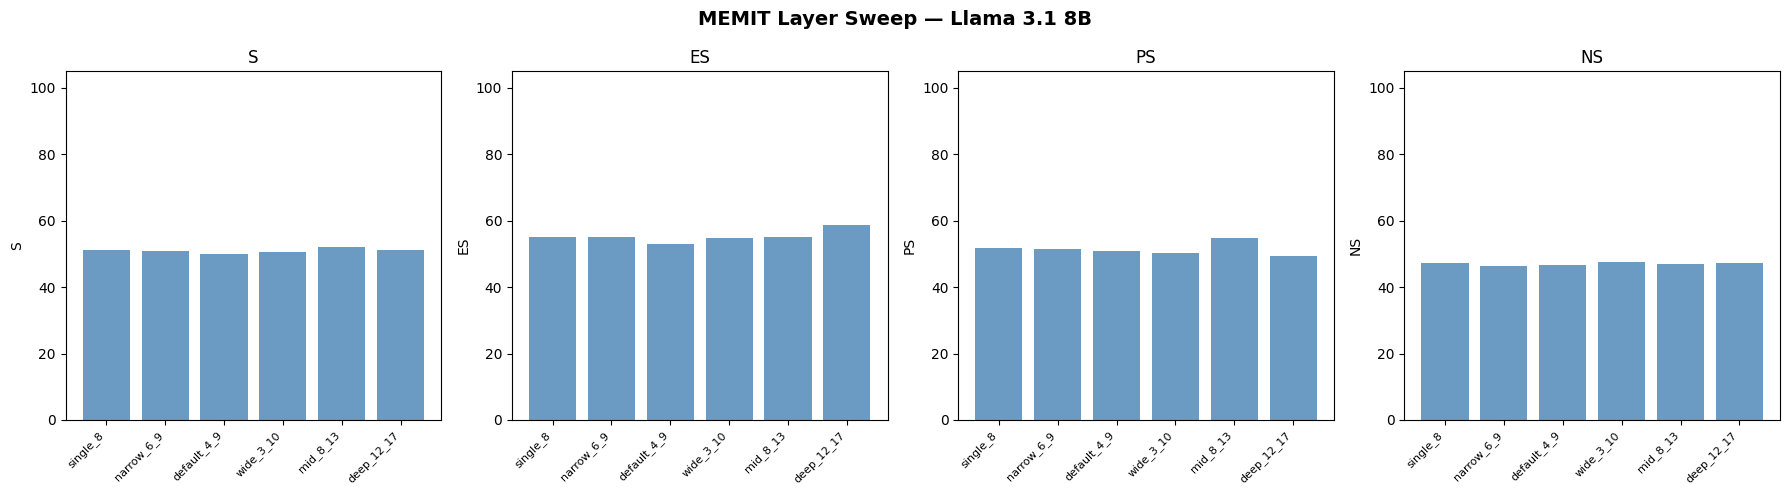

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle("MEMIT Layer Sweep — Llama 3.1 8B", fontsize=14, fontweight="bold")

config_names = list(layer_sweep_results.keys())

for idx, metric in enumerate(["S", "ES", "PS", "NS"]):
    ax = axes[idx]
    values = [layer_sweep_results[c]["metrics"][metric] for c in config_names]
    ax.bar(range(len(config_names)), values, color="steelblue", alpha=0.8)
    ax.set_xticks(range(len(config_names)))
    ax.set_xticklabels(config_names, rotation=45, ha="right", fontsize=8)
    ax.set_ylabel(metric)
    ax.set_title(metric)
    ax.set_ylim(0, 105)

plt.tight_layout()
plt.savefig("layer_sweep_results.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Sweep (b): λ (mom2_update_weight) Sweep

λ controls the tradeoff between inserting new associations and preserving old ones.
The paper uses λ=15,000 for GPT-J. We test whether this transfers to Llama.

In [ ]:
best_layer_config = max(layer_sweep_results.items(), key=lambda x: x[1]["metrics"]["S"])
best_layers = best_layer_config[1]["layers"]
print(f"Using best layers from sweep (a): {best_layers} (config: {best_layer_config[0]})")

lambda_values = [1000, 5000, 15000, 50000]
NUM_EDITS_LAMBDA_SWEEP = 100
lambda_sweep_results = {}

for lam in lambda_values:
    print(f"\n{'='*60}")
    print(f"Lambda = {lam}")
    print(f"{'='*60}")

    hparams = MEMITHyperParams.from_json("hparams/MEMIT/meta-llama_Llama-3.1-8B.json")
    hparams.layers = best_layers
    hparams.mom2_update_weight = lam

    results = run_memit_eval(model, tok, hparams, ds, num_edits=NUM_EDITS_LAMBDA_SWEEP, skip_generation=True)

    metrics = compute_metrics(results)
    lambda_sweep_results[lam] = metrics
    print_metrics(metrics, f"lambda={lam}")

print("\n\nLambda sweep complete!")
print(f"\n{'Lambda':>10} {'ES':>6} {'PS':>6} {'NS':>6} {'S':>6}")
print("-" * 40)
for lam, m in lambda_sweep_results.items():
    print(f"{lam:>10} {m['ES']:>6.1f} {m['PS']:>6.1f} {m['NS']:>6.1f} {m['S']:>6.1f}")

Streaming output truncated to the last 5000 lines.
loss 9.705 = 9.654 + 0.011 + 0.04 avg prob of [ Spanish] 7.829657988622785e-05
loss 10.11 = 10.061 + 0.01 + 0.04 avg prob of [ Spanish] 5.068606333225034e-05
loss 8.706 = 8.654 + 0.012 + 0.04 avg prob of [ Spanish] 0.00018251730944029987
loss 6.949 = 6.898 + 0.011 + 0.04 avg prob of [ Spanish] 0.0010145476553589106
loss 6.488 = 6.438 + 0.01 + 0.04 avg prob of [ Spanish] 0.00160101184155792
loss 6.443 = 6.394 + 0.009 + 0.04 avg prob of [ Spanish] 0.0016737750265747309
loss 6.422 = 6.374 + 0.008 + 0.04 avg prob of [ Spanish] 0.0017076510703191161
loss 6.409 = 6.361 + 0.008 + 0.04 avg prob of [ Spanish] 0.001730279065668583
Init norm 9.4375 | Delta norm 7.078125 | Target norm 11.303213119506836
Computing right vector (v)
Lookup index found: 7 | Sentence: Which position does Daniel Royer play? They play as<|begin_of_text|> | Token:  play
Rewrite layer is 13
Tying optimization objective to 31
Recording initial value of v*
loss 18.078 = 18.0

### Lambda Sweep Visualization

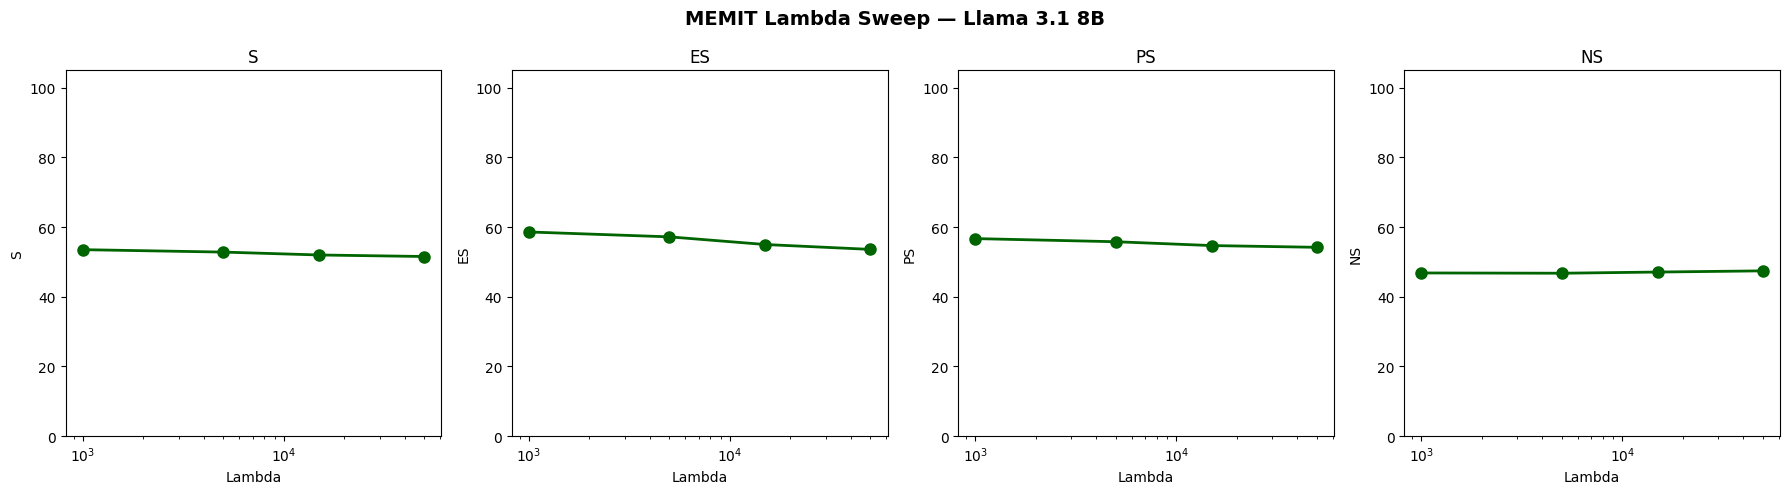

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle("MEMIT Lambda Sweep — Llama 3.1 8B", fontsize=14, fontweight="bold")

lambdas = list(lambda_sweep_results.keys())

for idx, metric in enumerate(["S", "ES", "PS", "NS"]):
    ax = axes[idx]
    values = [lambda_sweep_results[l][metric] for l in lambdas]
    ax.plot(lambdas, values, "o-", color="darkgreen", linewidth=2, markersize=8)
    ax.set_xlabel("Lambda")
    ax.set_xscale("log")
    ax.set_ylabel(metric)
    ax.set_title(metric)
    ax.set_ylim(0, 105)

plt.tight_layout()
plt.savefig("lambda_sweep_results.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

---
## Sweep (c): Edit Count Scaling

Test MEMIT at different edit batch sizes to see how Llama degrades compared to GPT-J.

In [ ]:
best_lambda = max(lambda_sweep_results.items(), key=lambda x: x[1]["S"])
print(f"Using best lambda: {best_lambda[0]} (S={best_lambda[1]['S']:.1f})")
print(f"Using best layers: {best_layers}")

edit_counts = [1, 10, 100, 500]
scaling_results = {}

for n_edits in edit_counts:
    print(f"\n{'='*60}")
    print(f"n_edits = {n_edits}")
    print(f"{'='*60}")

    hparams = MEMITHyperParams.from_json("hparams/MEMIT/meta-llama_Llama-3.1-8B.json")
    hparams.layers = best_layers
    hparams.mom2_update_weight = best_lambda[0]

    results = run_memit_eval(model, tok, hparams, ds, num_edits=n_edits, skip_generation=(n_edits > 100))

    metrics = compute_metrics(results)
    scaling_results[n_edits] = metrics
    print_metrics(metrics, f"n_edits={n_edits}")

print("\n\nEdit count scaling complete!")
print(f"\n{'n_edits':>10} {'ES':>6} {'PS':>6} {'NS':>6} {'S':>6}")
print("-" * 40)
for n, m in scaling_results.items():
    print(f"{n:>10} {m['ES']:>6.1f} {m['PS']:>6.1f} {m['NS']:>6.1f} {m['S']:>6.1f}")

Using best lambda: 1000 (S=53.5)
Using best layers: [8, 9, 10, 11, 12, 13]

n_edits = 1
data/attribute_snippets.json does not exist. Downloading from https://memit.baulab.info/data/dsets/attribute_snippets.json


100%|██████████| 883M/883M [00:08<00:00, 107MB/s]


100%|██████████| 10.5M/10.5M [00:00<00:00, 121MB/s]


100%|██████████| 30.2M/30.2M [00:00<00:00, 104MB/s]


Streaming output truncated to the last 5000 lines.
loss 15.367 = 15.319 + 0.009 + 0.039 avg prob of [ Hungary] 2.328722246147663e-07
loss 14.383 = 14.329 + 0.015 + 0.039 avg prob of [ Hungary] 6.473219400504604e-07
loss 14.399 = 14.333 + 0.028 + 0.039 avg prob of [ Hungary] 6.571258381882217e-07
loss 15.723 = 15.595 + 0.089 + 0.039 avg prob of [ Hungary] 3.77622740188599e-07
loss 15.098 = 15.042 + 0.017 + 0.039 avg prob of [ Hungary] 3.2819201578604407e-07
loss 14.976 = 14.889 + 0.049 + 0.039 avg prob of [ Hungary] 3.510189685584919e-07
loss 14.54 = 14.442 + 0.059 + 0.039 avg prob of [ Hungary] 5.767709012616251e-07
loss 14.463 = 14.391 + 0.033 + 0.039 avg prob of [ Hungary] 6.393887588274083e-07
loss 13.251 = 13.171 + 0.042 + 0.039 avg prob of [ Hungary] 2.1716887204092927e-06
loss 13.212 = 12.941 + 0.232 + 0.039 avg prob of [ Hungary] 2.661820644789259e-06
loss 13.235 = 13.163 + 0.033 + 0.039 avg prob of [ Hungary] 2.356259528824012e-06
loss 11.915 = 11.841 + 0.035 + 0.039 avg prob o

### Edit Count Scaling Visualization

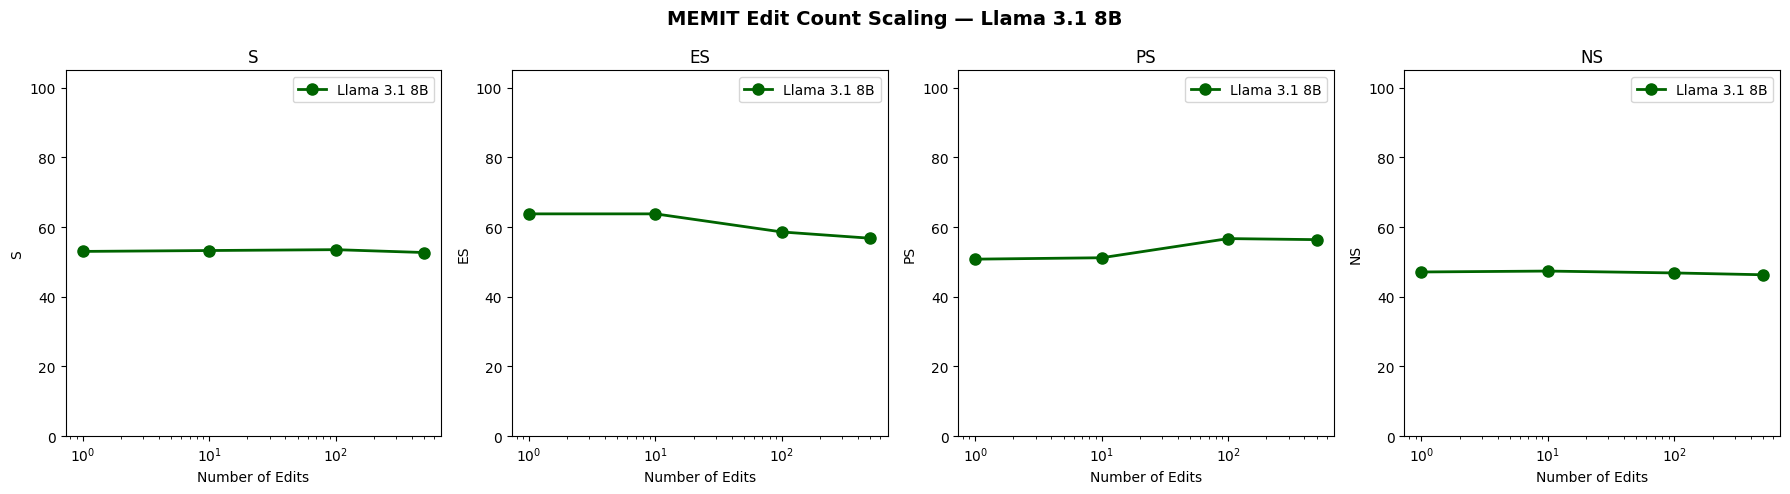

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle("MEMIT Edit Count Scaling — Llama 3.1 8B", fontsize=14, fontweight="bold")

edit_ns = sorted(scaling_results.keys())

for idx, metric in enumerate(["S", "ES", "PS", "NS"]):
    ax = axes[idx]
    values = [scaling_results[n][metric] for n in edit_ns]
    ax.plot(edit_ns, values, "o-", color="darkgreen", linewidth=2, markersize=8, label="Llama 3.1 8B")
    ax.set_xlabel("Number of Edits")
    ax.set_xscale("log")
    ax.set_ylabel(metric)
    ax.set_title(metric)
    ax.set_ylim(0, 105)
    ax.legend()

plt.tight_layout()
plt.savefig("scaling_results_llama.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Save All Results

In [ ]:
import json, os

def make_serializable(obj):
    if isinstance(obj, dict):
        return {str(k): make_serializable(v) for k, v in obj.items()}
    elif isinstance(obj, (list, tuple)):
        return [make_serializable(x) for x in obj]
    elif isinstance(obj, (int, float, str, bool)):
        return obj
    else:
        try:
            return float(obj)
        except (TypeError, ValueError):
            return str(obj)

all_sweep_results = {
    "model": "meta-llama/Llama-3.1-8B",
    "algorithm": "MEMIT",
    "dataset_size": DATASET_SIZE,
    "layer_sweep": make_serializable(layer_sweep_results),
    "lambda_sweep": make_serializable(lambda_sweep_results),
    "scaling_results": make_serializable(scaling_results),
    "best_config": {"layers": best_layers, "lambda": best_lambda[0]},
}

with open("llama_sweep_results.json", "w") as f:
    json.dump(all_sweep_results, f, indent=2)

try:
    import shutil
    SAVE_DIR = "/content/drive/MyDrive/MEMIT_Results"
    os.makedirs(SAVE_DIR, exist_ok=True)
    shutil.copy("llama_sweep_results.json", f"{SAVE_DIR}/llama_sweep_results.json")
    for png in ["layer_sweep_results.png", "lambda_sweep_results.png", "scaling_results_llama.png"]:
        if os.path.exists(png):
            shutil.copy(png, f"{SAVE_DIR}/{png}")
    print(f"All results saved to Google Drive: {SAVE_DIR}/")
except:
    print("Results saved locally as llama_sweep_results.json")

print(f"\nBest config: layers={best_layers}, lambda={best_lambda[0]}")

All results saved to Google Drive: /content/drive/MyDrive/MEMIT_Results/

Best config: layers=[8, 9, 10, 11, 12, 13], lambda=1000
